# Achieving High Quality Portfolio Optimization

This notebook combines the VQE-based quantum portfolio optimization implementation.

## 1. data_prep.py

Fetching data for 12 assets from 2024-01-01 to 2024-12-31...


[*********************100%***********************]  12 of 12 completed
/tmp/ipykernel_22791/2361173030.py:35: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change()



EXPECTED RETURN VECTOR (mu)
array([ 0.00129829,  0.00063003,  0.00142009,  0.00165567,  0.00458041,
        0.0014705 , -0.00010674,  0.00170935,  0.00173847,  0.00130019,
        0.00036145,  0.00156579])

COVARIANCE MATRIX (sigma)
array([[ 1.93064898e-04,  8.06667263e-05,  8.67699403e-05,
         8.14812754e-05,  1.14943993e-04,  3.14883559e-06,
         3.34869164e-06,  1.49798686e-08,  1.78477850e-06,
        -4.26146309e-06,  2.48644596e-05,  2.09410488e-05],
       [ 8.06667263e-05,  1.52769214e-04,  1.22908364e-04,
         1.47812366e-04,  1.84036050e-04,  2.90522683e-05,
        -2.45452952e-06, -1.91956975e-05, -7.39712748e-06,
         9.48160672e-06,  6.50081279e-06,  6.73924016e-06],
       [ 8.67699403e-05,  1.22908364e-04,  3.02691717e-04,
         1.63384833e-04,  1.77294186e-04,  3.60765918e-05,
         3.58298166e-05,  7.69957096e-06,  3.61668185e-05,
         5.51267779e-05,  2.80895270e-05,  5.20216650e-05],
       [ 8.14812754e-05,  1.47812366e-04,  1.63384833e-

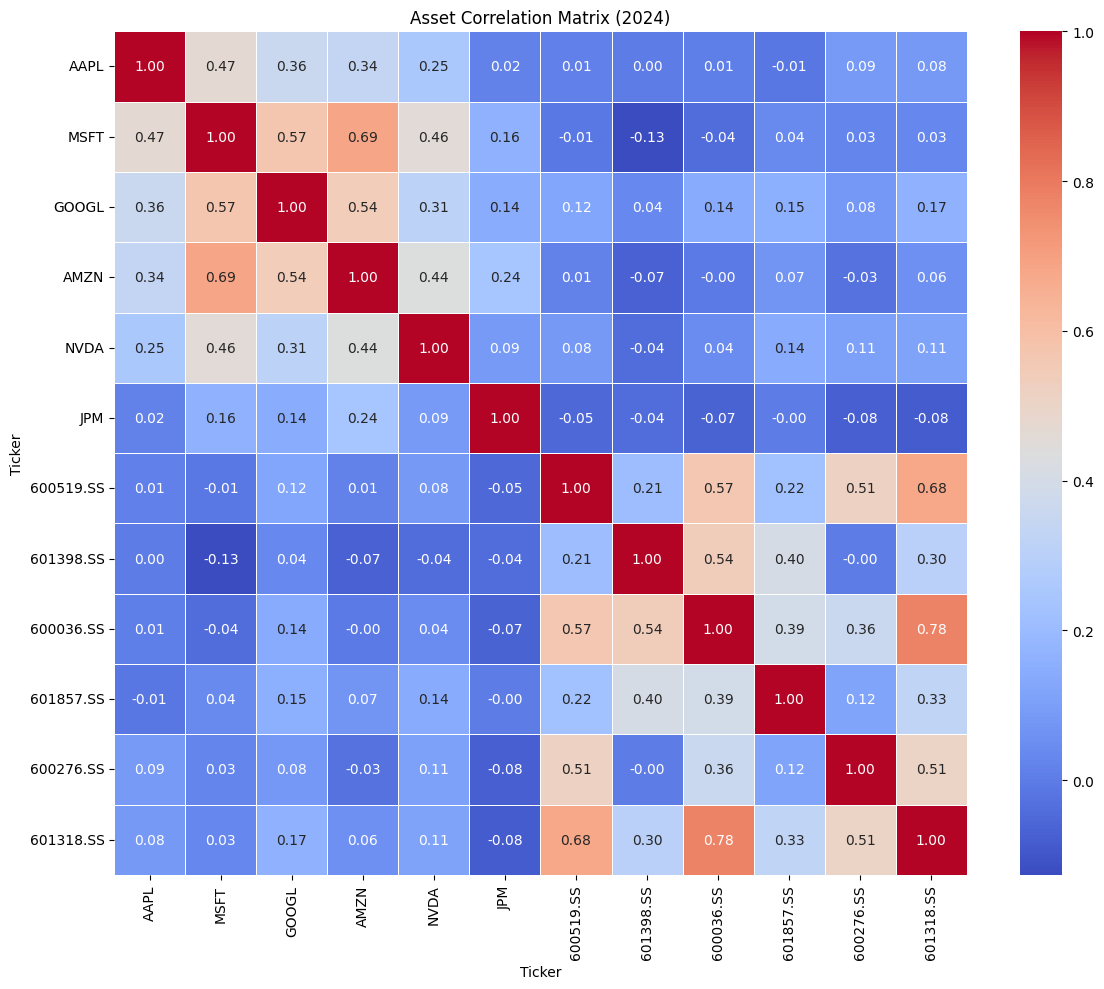

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def prepare_data():
    # Define assets as specified in the paper (N=12)
    us_equities = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "JPM"]
    china_a_shares = [
        "600519.SS", "601398.SS", "600036.SS", 
        "601857.SS", "600276.SS", "601318.SS"
    ]
    assets = us_equities + china_a_shares
    
    # Timeframe: Jan 1, 2024 to Dec 31, 2024
    start_date = "2024-01-01"
    end_date = "2024-12-31"
    
    print(f"Fetching data for {len(assets)} assets from {start_date} to {end_date}...")
    
    # Download data
    data_raw = yf.download(assets, start=start_date, end=end_date)
    
    if 'Adj Close' in data_raw.columns.levels[0]:
        data = data_raw['Adj Close']
    else:
        data = data_raw['Close']
    
    # Reorder columns to match the defined assets list order
    data = data[assets]
    
    # Calculate daily returns (Eq 1: percentage change)
    # r_ki = (P_ki - P_k-1,i) / P_k-1,i
    returns = data.pct_change()
    
    # Handle missing data: Drop NaNs (first row will always be NaN)
    # and any days where data might be missing for some assets due to different market holidays
    returns = returns.dropna()
    
    # Calculate Expected Return Vector (mu) - Eq 2
    mu = returns.mean().values
    
    # Calculate Covariance Matrix (sigma) - Eq 3
    # Note: numpy.cov expects variables in rows, so we transpose
    sigma = returns.cov().values
    
    # Output results in copy-pasteable format
    print("\n" + "="*50)
    print("EXPECTED RETURN VECTOR (mu)")
    print("="*50)
    print(repr(mu))
    
    print("\n" + "="*50)
    print("COVARIANCE MATRIX (sigma)")
    print("="*50)
    # Using numpy array2string for better formatting if needed, but repr is good for copy-paste
    print(repr(sigma))
    
    # Verification: Assets List
    print("\n" + "="*50)
    print("ASSETS ORDER")
    print("="*50)
    print(assets)

    # Visualization of Correlation Matrix
    correlation_matrix = returns.corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Asset Correlation Matrix (2024)")
    plt.tight_layout()
    plt.savefig("asset_correlation.png")
    print("\nCorrelation matrix saved to 'asset_correlation.png'")

if __name__ == "__main__":
    prepare_data()


## 2. build_hamiltonian.py

In [2]:
from qiskit.quantum_info import SparsePauliOp
import numpy as np

def build_hamiltonian(mu, sigma, risk_aversion=0.5, penalty=1.0):
    """
    Constructs the Ising Hamiltonian for the Portfolio Optimization problem.
    
    Args:
        mu (numpy.ndarray): Expected return vector of size N.
        sigma (numpy.ndarray): Covariance matrix of size NxN.
        risk_aversion (float): Risk aversion parameter (lambda).
        penalty (float): Penalty coefficient for the budget constraint.
        
    Returns:
        SparsePauliOp: The Ising Hamiltonian.
    """
    N = len(mu)
    # The budget B is fixed to N/2 as per the paper context
    B = N / 2
    
    # We will build the Hamiltonian as a list of (pauli_string, coeff)
    # and then sum them up into a SparsePauliOp.
    # Alternatively, and more efficiently, we can sum SparsePauliOp objects directly.
    
    # Initialize an empty Hamiltonian
    H = SparsePauliOp(['I' * N], coeffs=[0.0])
    
    # ---------------------------------------------------------
    # 1. Term: -lambda * sum(mu_i * x_i)
    # Mapping: x_i -> (I - Z_i) / 2
    # So: -lambda * mu_i * (I - Z_i)/2 = (-lambda * mu_i / 2) * I - (-lambda * mu_i / 2) * Z_i
    #                                  = (-lambda * mu_i / 2) * I + (lambda * mu_i / 2) * Z_i
    # ---------------------------------------------------------
    
    for i in range(N):
        # Construct Z_i operator
        # SparsePauliOp.from_list([("II...Z...II", 1)]) where Z is at index i
        # Qiskit uses little-endian (qubit 0 is rightmost), but usually for simple sums it doesn't matter 
        # as long as we are consistent. Let's use the standard index i from left to right for string construction 
        # or just use the position in the list.
        # String representation: "I" * (N - 1 - i) + "Z" + "I" * i (if 0 is rightmost)
        # Let's stick to Qiskit's standard: "Z" at index i implies the i-th qubit.
        
        op_zi = SparsePauliOp.from_sparse_list([("Z", [i], 1.0)], num_qubits=N)
        op_id = SparsePauliOp(['I' * N], coeffs=[1.0])
        
        # Coeffs for this term
        c_linear = -risk_aversion * mu[i]
        
        # x_i = 0.5 * (I - Z_i)
        term = c_linear * 0.5 * (op_id - op_zi)
        H += term

    # ---------------------------------------------------------
    # 2. Term: (1 - lambda) * sum_{i < j} (sigma_ij * x_i * x_j)
    # Mapping: x_i * x_j -> 0.25 * (I - Z_i) * (I - Z_j)
    #                     = 0.25 * (I - Z_i - Z_j + Z_i Z_j)
    # ---------------------------------------------------------
    
    for i in range(N):
        for j in range(i + 1, N):
            op_zi = SparsePauliOp.from_sparse_list([("Z", [i], 1.0)], num_qubits=N)
            op_zj = SparsePauliOp.from_sparse_list([("Z", [j], 1.0)], num_qubits=N)
            op_zizj = op_zi @ op_zj # Tensor product / composition
            op_id = SparsePauliOp(['I' * N], coeffs=[1.0])
            
            # Coeff for this term
            c_quad = (1 - risk_aversion) * sigma[i, j]
            
            # x_i * x_j term expansion
            # 0.25 * (I - Z_i - Z_j + Z_i*Z_j)
            term = c_quad * 0.25 * (op_id - op_zi - op_zj + op_zizj)
            H += term

    # ---------------------------------------------------------
    # 3. Term: p * (sum(x_i) - B)^2
    # Expansion: p * [ (sum x_i)^2 - 2B * sum x_i + B^2 ]
    # (sum x_i)^2 = sum (x_i^2) + 2 * sum_{i<j} (x_i * x_j)
    # Since x_i is binary, x_i^2 = x_i.
    # So: (sum x_i)^2 = sum x_i + 2 * sum_{i<j} x_i x_j
    # 
    # Full Penalty Term:
    # p * [ sum x_i + 2 * sum_{i<j} x_i x_j - 2B * sum x_i + B^2 ]
    # = p * [ (1 - 2B) * sum x_i + 2 * sum_{i<j} x_i x_j + B^2 ]
    # ---------------------------------------------------------
    
    # 3a. Constant part: p * B^2
    H += SparsePauliOp(['I' * N], coeffs=[penalty * (B**2)])
    
    # 3b. Linear part: p * (1 - 2B) * sum(x_i)
    coeff_linear_penalty = penalty * (1 - 2 * B)
    for i in range(N):
        op_zi = SparsePauliOp.from_sparse_list([("Z", [i], 1.0)], num_qubits=N)
        op_id = SparsePauliOp(['I' * N], coeffs=[1.0])
        
        # x_i = 0.5 * (I - Z_i)
        term = coeff_linear_penalty * 0.5 * (op_id - op_zi)
        H += term
        
    # 3c. Quadratic part: p * 2 * sum_{i<j} (x_i * x_j)
    # = 2p * sum_{i<j} (x_i * x_j)
    coeff_quad_penalty = 2 * penalty
    for i in range(N):
        for j in range(i + 1, N):
            op_zi = SparsePauliOp.from_sparse_list([("Z", [i], 1.0)], num_qubits=N)
            op_zj = SparsePauliOp.from_sparse_list([("Z", [j], 1.0)], num_qubits=N)
            op_zizj = op_zi @ op_zj
            op_id = SparsePauliOp(['I' * N], coeffs=[1.0])
            
            # x_i * x_j = 0.25 * (I - Z_i - Z_j + Z_i*Z_j)
            term = coeff_quad_penalty * 0.25 * (op_id - op_zi - op_zj + op_zizj)
            H += term

    # Simplify the Hamiltonian to combine like terms
    H = H.simplify()
    return H

if __name__ == "__main__":
    # Real data from Phase 1
    N = 12
    mu = np.array([
        0.00129829, 0.00063003, 0.00142009, 0.00165567, 0.00458041,
        0.0014705, -0.00010674, 0.00170935, 0.00173847, 0.00130019,
        0.00036145, 0.00156579
    ])
    
    sigma = np.array([
        [1.93065254e-04, 8.06667321e-05, 8.67697331e-05, 8.14811864e-05, 1.14943731e-04, 3.14880919e-06, 3.34852086e-06, 1.50490305e-08, 1.78463544e-06, -4.26159620e-06, 2.48643108e-05, 2.09408214e-05],
        [8.06667321e-05, 1.52769153e-04, 1.22908368e-04, 1.47812317e-04, 1.84036012e-04, 2.90522192e-05, -2.45438019e-06, -1.91957115e-05, -7.39709853e-06, 9.48176167e-06, 6.50059737e-06, 6.73923882e-06],
        [8.67697331e-05, 1.22908368e-04, 3.02691633e-04, 1.63384728e-04, 1.77293621e-04, 3.60765336e-05, 3.58302022e-05, 7.69963292e-06, 3.61670055e-05, 5.51268604e-05, 2.80899835e-05, 5.20217182e-05],
        [8.14811864e-05, 1.47812317e-04, 1.63384728e-04, 3.03478746e-04, 2.47351255e-04, 6.09185345e-05, 4.25115695e-06, -1.50900366e-05, -1.30070811e-06, 2.50807932e-05, -9.15458602e-06, 1.73895365e-05],
        [1.14943731e-04, 1.84036012e-04, 1.77293621e-04, 2.47351255e-04, 1.05798856e-03, 4.11219245e-05, 4.41488486e-05, -1.56736230e-05, 2.02663425e-05, 9.39947198e-05, 6.88672246e-05, 6.60165422e-05],
        [3.14880919e-06, 2.90522192e-05, 3.60765336e-05, 6.09185345e-05, 4.11219245e-05, 2.12766228e-04, -1.27275706e-05, -7.30702607e-06, -1.48841441e-05, -9.23187646e-07, -2.27303193e-05, -2.20272177e-05],
        [3.34852086e-06, -2.45438019e-06, 3.58302022e-05, 4.25115695e-06, 4.41488486e-05, -1.27275706e-05, 2.83836809e-04, 4.24976797e-05, 1.43912160e-04, 7.75746777e-05, 1.73707021e-04, 2.05431126e-04],
        [1.50490305e-08, -1.91957115e-05, 7.69963292e-06, -1.50900366e-05, -1.56736230e-05, -7.30702607e-06, 4.24976797e-05, 1.51073599e-04, 9.93120476e-05, 1.02098869e-04, -1.09195027e-07, 6.73227594e-05],
        [1.78463544e-06, -7.39709853e-06, 3.61670055e-05, -1.30070811e-06, 2.02663425e-05, -1.48841441e-05, 1.43912160e-04, 9.93120476e-05, 2.26926540e-04, 1.21574865e-04, 1.08965226e-04, 2.10847667e-04],
        [-4.26159620e-06, 9.48176167e-06, 5.51268604e-05, 2.50807932e-05, 9.39947198e-05, -9.23187646e-07, 7.75746777e-05, 1.02098869e-04, 1.21574865e-04, 4.23158499e-04, 4.84957737e-05, 1.20344712e-04],
        [2.48643108e-05, 6.50059737e-06, 2.80899835e-05, -9.15458602e-06, 6.88672246e-05, -2.27303193e-05, 1.73707021e-04, -1.09195027e-07, 1.08965226e-04, 4.84957737e-05, 4.05630777e-04, 1.83171953e-04],
        [2.09408214e-05, 6.73923882e-06, 5.20217182e-05, 1.73895365e-05, 6.60165422e-05, -2.20272177e-05, 2.05431126e-04, 6.73227594e-05, 2.10847667e-04, 1.20344712e-04, 1.83171953e-04, 3.23460020e-04]
    ])
    
    print(f"Building Hamiltonian for N={N} assets with Budget B={N/2}...")
    
    # Build Hamiltonian using standard parameters
    hamiltonian = build_hamiltonian(mu, sigma, risk_aversion=0.5, penalty=1.0)
    
    print("\nHamiltonian Construction Complete.")
    print(f"Number of qubits: {hamiltonian.num_qubits}")
    print(f"Number of Pauli terms: {len(hamiltonian.paulis)}")
    
    # Verify complexity: Should be roughly N + N*(N-1)/2 + 1 terms (Linear + Quad + Const)
    # For N=12: 12 + 66 + 1 = 79 terms approximately (might be less due to cancellations or groupings)
    expected_terms_approx = N + (N * (N - 1) / 2) + 1
    print(f"Expected approx number of terms (N + NC2 + 1): {int(expected_terms_approx)}")
    
    # Print first few terms to check
    print("\nFirst 5 terms of the Hamiltonian:")
    print(hamiltonian[:5])


Building Hamiltonian for N=12 assets with Budget B=6.0...

Hamiltonian Construction Complete.
Number of qubits: 12
Number of Pauli terms: 79
Expected approx number of terms (N + NC2 + 1): 79

First 5 terms of the Hamiltonian:
SparsePauliOp(['IIIIIIIIIIII', 'IIIIIIIIIIIZ', 'IIIIIIIIIIZI', 'IIIIIIIIIZII', 'IIIIIIIIZIII'],
              coeffs=[2.99606358e+00+0.j, 2.72859758e-04+0.j, 8.77387430e-05+0.j,
 2.54851452e-04+0.j, 3.23651978e-04+0.j])


## 3. build_ansatz.py

In [ ]:
from qiskit.circuit.library import TwoLocal

def get_ansatz(num_qubits=12):
    """
    Constructs the Two-Local Ansatz as described in the paper.
    
    Specifications:
    - Rotation Layer: Ry followed by Rz gates.
    - Entanglement Layer: CNOT (cx) gates with linear connectivity.
    - Repetitions: 3 layers.
    - Visuals: Barriers inserted for clarity.
    
    Args:
        num_qubits (int): Number of qubits (assets). Default is 12.
        
    Returns:
        TwoLocal: The constructed variational circuit.
    """
    # Define the rotation blocks
    rotation_blocks = ['ry', 'rz']
    
    # Define the entanglement blocks
    entanglement_blocks = 'cx'
    
    # Define the entanglement strategy (linear: 0-1, 1-2, ...)
    entanglement = 'linear'
    
    # Define the number of repetitions (layers)
    reps = 3
    
    # Construct the TwoLocal circuit
    ansatz = TwoLocal(
        num_qubits=num_qubits,
        rotation_blocks=rotation_blocks,
        entanglement_blocks=entanglement_blocks,
        entanglement=entanglement,
        reps=reps,
        insert_barriers=True,
        parameter_prefix='theta'
    )
    
    return ansatz

if __name__ == "__main__":
    # Parameters
    N = 12
    
    print(f"Constructing Two-Local Ansatz for {N} qubits...")
    ansatz = get_ansatz(num_qubits=N)
    
    # Decompose to see elementary gates
    decomposed_ansatz = ansatz.decompose()
    
    print("\nAnsatz Properties:")
    print(f"Number of qubits: {decomposed_ansatz.num_qubits}")
    print(f"Number of parameters: {ansatz.num_parameters}")
    print(f"Circuit depth (decomposed): {decomposed_ansatz.depth()}")
    
    print("\nCircuit Diagram (Text):")
    print(decomposed_ansatz.draw(output='text'))


Constructing Two-Local Ansatz for 12 qubits...

Ansatz Properties:
Number of qubits: 12
Number of parameters: 96
Circuit depth (decomposed): 41

Circuit Diagram (Text):
       ┌──────────────┐┌───────────────┐ ░                                    »
 q_0: ─┤ Ry(theta[0]) ├┤ Rz(theta[12]) ├─░───■────────────────────────────────»
       ├──────────────┤├───────────────┤ ░ ┌─┴─┐                              »
 q_1: ─┤ Ry(theta[1]) ├┤ Rz(theta[13]) ├─░─┤ X ├──■───────────────────────────»
       ├──────────────┤├───────────────┤ ░ └───┘┌─┴─┐                         »
 q_2: ─┤ Ry(theta[2]) ├┤ Rz(theta[14]) ├─░──────┤ X ├──■──────────────────────»
       ├──────────────┤├───────────────┤ ░      └───┘┌─┴─┐                    »
 q_3: ─┤ Ry(theta[3]) ├┤ Rz(theta[15]) ├─░───────────┤ X ├──■─────────────────»
       ├──────────────┤├───────────────┤ ░           └───┘┌─┴─┐               »
 q_4: ─┤ Ry(theta[4]) ├┤ Rz(theta[16]) ├─░────────────────┤ X ├──■────────────»
       ├──────────────┤├───────

/tmp/ipykernel_22791/2075042562.py:32: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(


## 4. vqe_cma_es.py

In [4]:
import numpy as np
import cma
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector

# Import our previous modules
from build_hamiltonian import build_hamiltonian
from build_ansatz import get_ansatz

def get_diagonal_hamiltonian(hamiltonian):
    """
    Extracts the diagonal of the Hamiltonian matrix efficiently.
    Since H is an Ising Hamiltonian, it is diagonal in the Z-basis.
    """
    # For N=12, 2^12 = 4096 is small enough to store the full diagonal.
    # We can get it by summing the diagonals of each Pauli term.
    
    num_qubits = hamiltonian.num_qubits
    dim = 2**num_qubits
    diagonal = np.zeros(dim, dtype=complex)
    
    for pauli, coeff in zip(hamiltonian.paulis, hamiltonian.coeffs):
        # Convert Pauli string to diagonal Z-vector
        # 'I' -> 1, 'Z' -> -1
        # The diagonal is the tensor product of these values.
        
        # We can construct the diagonal for this term efficiently
        term_diag = np.ones(1, dtype=complex)
        
        # Iterate through the pauli string (reversed because qiskit is little-endian)
        # However, SparsePauliOp is usually stored such that index 0 is the rightmost in string but 
        # let's rely on the label.
        # String 'Z...Z' corresponds to qubits N-1 ... 0
        
        # A safer way using Qiskit's built-in functionality if available, 
        # or just manual tensor product.
        
        # Let's iterate from qubit 0 to N-1
        # Qiskit Pauli string index 0 is the rightmost char (qubit 0).
        
        p_str = pauli.to_label()
        
        # We build from qubit 0 (last char) up to N-1 (first char)
        current_diag = np.array([1])
        
        for char in reversed(p_str):
            if char == 'I':
                op = np.array([1, 1])
            elif char == 'Z':
                op = np.array([1, -1])
            else:
                raise ValueError("Hamiltonian must be Ising (I/Z only).")
            
            # Tensor product: new = op (tensor) current
            # But numpy kronecker is A (tensor) B. 
            # If we want qubit N-1 (tensor) ... (tensor) qubit 0
            # We are building from 0 up. So next qubit is to the left (A).
            current_diag = np.kron(op, current_diag)
            
        diagonal += coeff * current_diag
        
    return np.real(diagonal)

def bitstring_to_int(bitstring):
    """Converts a bitstring '101...' to integer."""
    return int(bitstring, 2)

def cost_function(parameters, ansatz, diagonal_energies, sampler, shots=1000):
    """
    WCVaR Cost Function using Rank-Based Exponential Weighting.
    """
    # 1. Bind parameters
    # ansatz.assign_parameters(parameters) is deprecated/slow in loop
    # We use the sampler's binding mechanism
    
    # 2. Measure (Simulate)
    # Using StatevectorSampler for simulation
    # Primitive V2 run() takes a list of pubs (Primitive Unified Blocs)
    # Each pub is (circuit, parameter_values)
    job = sampler.run([(ansatz, parameters)], shots=shots)
    result = job.result()
    
    # Get counts/bitstrings from the first (and only) pub result
    data = result[0].data
    # bitstrings = data.meas.get_bitstrings() # This gives list of all shots
    # Alternatively, get counts directly if supported, but Sampler V2 returns bitstrings/counts
    
    counts = data.meas.get_counts()
    
    # 3. Process Data
    # Expand to list of energies
    sampled_energies = []
    
    for bitstring, count in counts.items():
        # Calculate Energy
        # Map bitstring to index: '0...0' -> 0, '0...1' -> 1
        # Note: Qiskit bitstrings are usually Little Endian in print? 
        # No, Qiskit '01' means q1=0, q0=1 usually.
        # Our diagonal construction was [qN-1 ... q0].
        # So '0...1' (q0=1) should map to index 1.
        
        idx = int(bitstring, 2)
        energy = diagonal_energies[idx]
        
        sampled_energies.extend([energy] * count)
        
    # 4. Sort Energies
    sampled_energies.sort()
    K = len(sampled_energies) # Should be shots
    
    # 5. Weighting (WCVaR)
    # Constants from instruction
    alpha = 0.25
    beta = 1.0
    
    # Cutoff index
    cutoff = int(np.ceil(alpha * K))
    tail_energies = sampled_energies[:cutoff]
    
    # Weights: w_k = exp(-beta * k) for k = 1 to cutoff
    # Note: k is 1-based rank
    ks = np.arange(1, cutoff + 1)
    weights = np.exp(-beta * ks)
    
    # Normalize weights
    weights /= np.sum(weights)
    
    # Weighted Sum
    wcvar = np.sum(weights * tail_energies)
    
    return wcvar

def main():
    # ---------------------------------------------------------
    # 1. Setup Data & Hamiltonian
    # ---------------------------------------------------------
    print("Setting up Portfolio Optimization problem...")
    
    # Real data from Phase 1
    N = 12
    mu = np.array([
        0.00129829, 0.00063003, 0.00142009, 0.00165567, 0.00458041,
        0.0014705, -0.00010674, 0.00170935, 0.00173847, 0.00130019,
        0.00036145, 0.00156579
    ])
    
    sigma = np.array([
        [1.93065254e-04, 8.06667321e-05, 8.67697331e-05, 8.14811864e-05, 1.14943731e-04, 3.14880919e-06, 3.34852086e-06, 1.50490305e-08, 1.78463544e-06, -4.26159620e-06, 2.48643108e-05, 2.09408214e-05],
        [8.06667321e-05, 1.52769153e-04, 1.22908368e-04, 1.47812317e-04, 1.84036012e-04, 2.90522192e-05, -2.45438019e-06, -1.91957115e-05, -7.39709853e-06, 9.48176167e-06, 6.50059737e-06, 6.73923882e-06],
        [8.67697331e-05, 1.22908368e-04, 3.02691633e-04, 1.63384728e-04, 1.77293621e-04, 3.60765336e-05, 3.58302022e-05, 7.69963292e-06, 3.61670055e-05, 5.51268604e-05, 2.80899835e-05, 5.20217182e-05],
        [8.14811864e-05, 1.47812317e-04, 1.63384728e-04, 3.03478746e-04, 2.47351255e-04, 6.09185345e-05, 4.25115695e-06, -1.50900366e-05, -1.30070811e-06, 2.50807932e-05, -9.15458602e-06, 1.73895365e-05],
        [1.14943731e-04, 1.84036012e-04, 1.77293621e-04, 2.47351255e-04, 1.05798856e-03, 4.11219245e-05, 4.41488486e-05, -1.56736230e-05, 2.02663425e-05, 9.39947198e-05, 6.88672246e-05, 6.60165422e-05],
        [3.14880919e-06, 2.90522192e-05, 3.60765336e-05, 6.09185345e-05, 4.11219245e-05, 2.12766228e-04, -1.27275706e-05, -7.30702607e-06, -1.48841441e-05, -9.23187646e-07, -2.27303193e-05, -2.20272177e-05],
        [3.34852086e-06, -2.45438019e-06, 3.58302022e-05, 4.25115695e-06, 4.41488486e-05, -1.27275706e-05, 2.83836809e-04, 4.24976797e-05, 1.43912160e-04, 7.75746777e-05, 1.73707021e-04, 2.05431126e-04],
        [1.50490305e-08, -1.91957115e-05, 7.69963292e-06, -1.50900366e-05, -1.56736230e-05, -7.30702607e-06, 4.24976797e-05, 1.51073599e-04, 9.93120476e-05, 1.02098869e-04, -1.09195027e-07, 6.73227594e-05],
        [1.78463544e-06, -7.39709853e-06, 3.61670055e-05, -1.30070811e-06, 2.02663425e-05, -1.48841441e-05, 1.43912160e-04, 9.93120476e-05, 2.26926540e-04, 1.21574865e-04, 1.08965226e-04, 2.10847667e-04],
        [-4.26159620e-06, 9.48176167e-06, 5.51268604e-05, 2.50807932e-05, 9.39947198e-05, -9.23187646e-07, 7.75746777e-05, 1.02098869e-04, 1.21574865e-04, 4.23158499e-04, 4.84957737e-05, 1.20344712e-04],
        [2.48643108e-05, 6.50059737e-06, 2.80899835e-05, -9.15458602e-06, 6.88672246e-05, -2.27303193e-05, 1.73707021e-04, -1.09195027e-07, 1.08965226e-04, 4.84957737e-05, 4.05630777e-04, 1.83171953e-04],
        [2.09408214e-05, 6.73923882e-06, 5.20217182e-05, 1.73895365e-05, 6.60165422e-05, -2.20272177e-05, 2.05431126e-04, 6.73227594e-05, 2.10847667e-04, 1.20344712e-04, 1.83171953e-04, 3.23460020e-04]
    ])
    
    # Build Hamiltonian
    hamiltonian = build_hamiltonian(mu, sigma, risk_aversion=0.5, penalty=1.0)
    
    # Pre-compute Diagonal
    print("Pre-computing Hamiltonian diagonal (this may take a moment)...")
    diagonal_energies = get_diagonal_hamiltonian(hamiltonian)
    print("Diagonal computed.")
    
    # ---------------------------------------------------------
    # 2. Setup Ansatz
    # ---------------------------------------------------------
    ansatz = get_ansatz(num_qubits=N)
    ansatz.measure_all() # Ensure we measure all qubits
    
    # ---------------------------------------------------------
    # 3. Optimization with CMA-ES
    # ---------------------------------------------------------
    print("\nStarting CMA-ES Optimization (max 500 evals)...")
    
    # Initial parameters
    num_params = ansatz.num_parameters
    x0 = np.random.rand(num_params) * 2 * np.pi # Random start in [0, 2pi]
    sigma0 = 0.5 # Initial step size
    
    # Sampler
    sampler = StatevectorSampler()
    
    # Wrapper for CMA-ES
    # CMA-ES minimizes, so we return WCVaR directly
    def objective(x):
        return cost_function(x, ansatz, diagonal_energies, sampler, shots=1000)
    
    # Run Optimization
    # options={'maxfevals': 500, 'verbose': -9} to reduce noise if needed
    es = cma.fmin(objective, x0, sigma0, options={'maxfevals': 500, 'verb_disp': 50})
    
    best_params = es[0]
    best_wcvar = es[1]
    
    print("\n" + "="*50)
    print("OPTIMIZATION RESULTS")
    print("="*50)
    print(f"Best WCVaR: {best_wcvar}")
    
    # ---------------------------------------------------------
    # 4. Final Evaluation
    # ---------------------------------------------------------
    print("\nEvaluating Best Solution...")
    job = sampler.run([(ansatz, best_params)], shots=2000)
    result = job.result()
    counts = result[0].data.meas.get_counts()
    
    # Find most frequent bitstring
    best_bitstring = max(counts, key=counts.get)
    
    # Find lowest energy bitstring sampled
    min_energy = float('inf')
    best_energy_bitstring = ""
    
    for bs in counts:
        idx = int(bs, 2)
        en = diagonal_energies[idx]
        if en < min_energy:
            min_energy = en
            best_energy_bitstring = bs
            
    print(f"Most Frequent Bitstring: {best_bitstring}")
    print(f"Lowest Energy Bitstring: {best_energy_bitstring}")
    print(f"Minimum Energy: {min_energy}")
    
    # Interpret Portfolio
    # Bitstring '101...' means: q11 q10 ... q0
    # Asset order in Phase 1 was:
    assets = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'JPM', '600519.SS', '601398.SS', '600036.SS', '601857.SS', '600276.SS', '601318.SS']
    
    # Reverse bitstring to match array order (q0 is first asset?)
    # Wait, usually q0 is the LEAST significant bit in integer conversion, but printed as Rightmost.
    # If we mapped x_i -> Z_i, then q_i corresponds to x_i.
    # Qiskit print "100" means q2=1, q1=0, q0=0.
    # So if string is "00...01" (q0=1), it means Asset 0 is selected.
    # The string is length N. Index i corresponds to q_i.
    # In the string representation, q0 is at index -1 (last).
    
    selected_assets = []
    # Iterate from right (q0) to left
    bs_reversed = best_energy_bitstring[::-1] # Now index 0 is q0
    
    print("\nSelected Portfolio (from Lowest Energy Sample):")
    for i, bit in enumerate(bs_reversed):
        if bit == '1':
            selected_assets.append(assets[i])
            
    print(selected_assets)
    print(f"Number of assets selected: {len(selected_assets)}")

if __name__ == "__main__":
    main()


Setting up Portfolio Optimization problem...
Pre-computing Hamiltonian diagonal (this may take a moment)...
Diagonal computed.

Starting CMA-ES Optimization (max 500 evals)...
(8_w,17)-aCMA-ES (mu_w=5.1,w_1=31%) in dimension 96 (seed=1100020, Mon Dec 29 15:23:03 2025)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     17 -5.964175189308230e-03 1.0e+00 4.81e-01  5e-01  5e-01 0:01.2
    2     34 -5.934034840544615e-03 1.0e+00 4.64e-01  5e-01  5e-01 0:02.4
    3     51 -5.909026516202062e-03 1.0e+00 4.50e-01  4e-01  5e-01 0:03.8
    6    102 -5.982275033801260e-03 1.0e+00 4.25e-01  4e-01  4e-01 0:07.9
    9    153 -5.945429544457179e-03 1.0e+00 4.13e-01  4e-01  4e-01 0:12.4
   13    221 -5.982951270741560e-03 1.1e+00 4.04e-01  4e-01  4e-01 0:18.0
   17    289 -5.982963007401892e-03 1.1e+00 3.98e-01  4e-01  4e-01 0:24.2
   23    391 -5.982963038225766e-03 1.1e+00 3.89e-01  4e-01  4e-01 0:32.5
   30    510 -5.982963073189239e-03 1.2e+00 3.97e-01  4e-01  4e-01 

## 5. visualize_portfolio.py

Asset Allocation:
 0 | AAPL         | Exp Ret: 0.001298 |         
 1 | MSFT         | Exp Ret: 0.000630 |         
 2 | GOOGL        | Exp Ret: 0.001420 |         
 3 | AMZN         | Exp Ret: 0.001656 | SELECTED
 4 | NVDA         | Exp Ret: 0.004580 | SELECTED
 5 | JPM          | Exp Ret: 0.001471 | SELECTED
 6 | 600519.SS    | Exp Ret: -0.000107 |         
 7 | 601398.SS    | Exp Ret: 0.001709 | SELECTED
 8 | 600036.SS    | Exp Ret: 0.001738 | SELECTED
 9 | 601857.SS    | Exp Ret: 0.001300 |         
10 | 600276.SS    | Exp Ret: 0.000361 |         
11 | 601318.SS    | Exp Ret: 0.001566 | SELECTED

Visualization saved to: vqe_optimal_portfolio.png


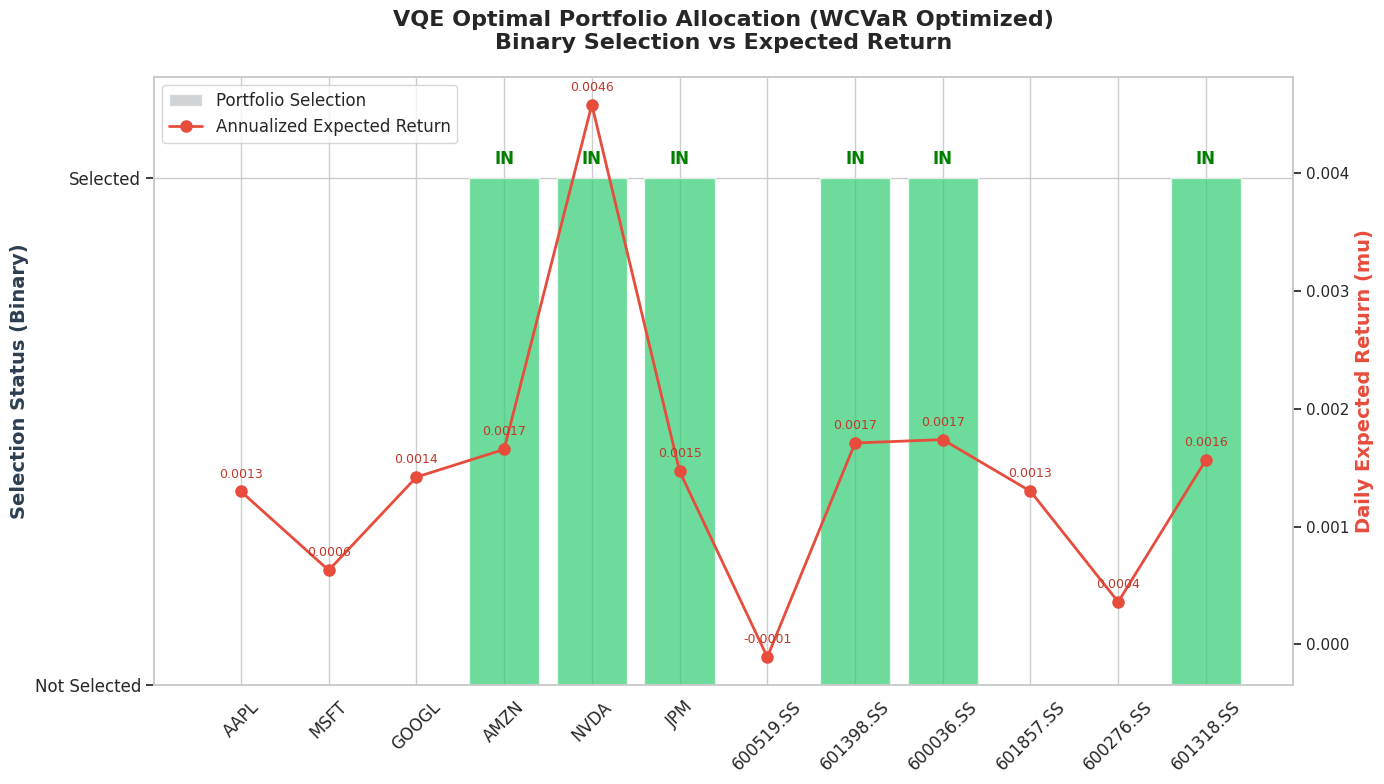

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_portfolio():
    # =========================================================================
    # USER INPUT SECTION
    # =========================================================================
    
    # 1. Tickers (Fixed)
    tickers = [
        'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'JPM', 
        '600519.SS', '601398.SS', '600036.SS', '601857.SS', '600276.SS', '601318.SS'
    ]
    
    # 2. Expected Returns (mu) - Values from Phase 1
    # Replace this array if you have new data
    mu = np.array([
        0.00129829, 0.00063003, 0.00142009, 0.00165567, 0.00458041,
        0.0014705, -0.00010674, 0.00170935, 0.00173847, 0.00130019,
        0.00036145, 0.00156579
    ])
    
    # 3. Optimal Bitstring
    # Paste the "Lowest Energy Bitstring" from the VQE output here
    # Example: "100110111000"
    optimal_bitstring = "100110111000" 
    
    # =========================================================================
    # PROCESSING
    # =========================================================================
    
    # Qiskit bitstrings are often printed little-endian (rightmost bit is qubit 0).
    # In our mapping, qubit i corresponds to asset i.
    # If the string is "qN...q0", we need to reverse it to get "q0...qN" 
    # to match the tickers list [Asset 0, Asset 1, ...].
    
    # Check mapping logic from previous phase:
    # Bitstring: 100110111000
    # Reversed:  000111011001
    # Indices:   012345678901
    # Selected: 3, 4, 5, 7, 8, 11
    
    # Reverse string to align with list index 0 -> N
    binary_selection = np.array([int(bit) for bit in optimal_bitstring[::-1]])
    
    print("Asset Allocation:")
    for i, ticker in enumerate(tickers):
        status = "SELECTED" if binary_selection[i] == 1 else "        "
        print(f"{i:2d} | {ticker:<12} | Exp Ret: {mu[i]:.6f} | {status}")

    # =========================================================================
    # VISUALIZATION
    # =========================================================================
    
    sns.set_theme(style="whitegrid")
    fig, ax1 = plt.subplots(figsize=(14, 8))
    
    # 1. Bar Chart: Binary Decision (Selected vs Not Selected)
    # Create colors: Green for Selected, Light Grey for Not Selected
    colors = ['#2ecc71' if x == 1 else '#bdc3c7' for x in binary_selection]
    
    # Plot bars
    bars = ax1.bar(tickers, binary_selection, color=colors, alpha=0.7, label='Portfolio Selection')
    
    # Customize Primary Axis (Selection)
    ax1.set_ylabel('Selection Status (Binary)', fontsize=14, fontweight='bold', color='#2c3e50')
    ax1.set_ylim(0, 1.2)
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(['Not Selected', 'Selected'], fontsize=12)
    ax1.tick_params(axis='x', rotation=45, labelsize=12)
    
    # Add labels on top of bars
    for bar, selected in zip(bars, binary_selection):
        height = bar.get_height()
        if selected:
            ax1.text(bar.get_x() + bar.get_width()/2., 1.02, 'IN', 
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='green')
    
    # 2. Line Plot: Expected Returns (Secondary Axis)
    ax2 = ax1.twinx()
    
    # Plot line/scatter
    ax2.plot(tickers, mu, color='#e74c3c', marker='o', linestyle='-', linewidth=2, markersize=8, label='Annualized Expected Return')
    
    # Highlight high-return points
    for i, val in enumerate(mu):
        ax2.annotate(f"{val:.4f}", (i, val), xytext=(0, 10), textcoords='offset points', 
                     ha='center', fontsize=9, color='#c0392b')

    # Customize Secondary Axis (Returns)
    ax2.set_ylabel('Daily Expected Return (mu)', fontsize=14, fontweight='bold', color='#e74c3c')
    ax2.grid(False) # Turn off grid for second axis to avoid clutter
    
    # Title and Layout
    plt.title('VQE Optimal Portfolio Allocation (WCVaR Optimized)\nBinary Selection vs Expected Return', fontsize=16, fontweight='bold', pad=20)
    
    # Legend
    # Combine legends from both axes
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=12)
    
    plt.tight_layout()
    
    # Save output
    output_filename = "vqe_optimal_portfolio.png"
    plt.savefig(output_filename, dpi=300)
    print(f"\nVisualization saved to: {output_filename}")

if __name__ == "__main__":
    visualize_portfolio()
